In [1]:
import sys
!{sys.executable} -m pip install --upgrade https://github.com/aparrish/bezmerizing/archive/master.zip

  Using cached https://github.com/aparrish/bezmerizing/archive/master.zip
  Created wheel for bezmerizing: filename=bezmerizing-0.1.1-py3-none-any.whl size=17284 sha256=acb6318974c16024f647dcdfd4f892027fbc019ac559259339e2d3d593af4389
  Stored in directory: /private/var/folders/3v/lxt4vwb95zs2ttfnbk5g_pch0000gn/T/pip-ephem-wheel-cache-hx3avzde/wheels/74/5a/7d/4a62c2490b6c6061916e41ae070caaed12664893aef1a56d7c
Successfully built bezmerizing
  Attempting uninstall: bezmerizing
    Found existing installation: bezmerizing 0.1.1
    Uninstalling bezmerizing-0.1.1:
      Successfully uninstalled bezmerizing-0.1.1


In [2]:
from flat import document, rgb, rgba, font, strike, shape
from flat.command import moveto, quadto, curveto, lineto, closepath
from bezmerizing import Polyline, Path
import numpy as np
from copy import copy
from numpy.random import uniform, normal, choice

In [3]:
from IPython.display import SVG, display
def show(page):
    display(SVG(page.svg()))

In [4]:
f = font.open('Pacifico-Regular.ttf')

In [5]:
def glyphcommands(f, ch):
    return Path([copy(cmd) for cmd in f.glyph(f.charmap[ord(ch)])])
def advancefor(f, ch):
    return f.advances[f.charmap[ord(ch)]]



In [6]:
myText = "ABCDE 12345"
numLets = len(myText)

letHalves = [] #holds first half of glyph commands per letter
let2ndHalves = [] #holds second half of glyph commands per letter

for let in range(numLets): #for each letter:
    letCommands = glyphcommands(f,myText[let]).commands
    
    if let == 0: #if first letter, send all stroke info
        letHalves.append(letCommands[0:int(len(letCommands)/2)]) #put 1st half of letter's glyphcommands into an list
    else: #if not first, ignore first moveto command, send rest of info
        letHalves.append(letCommands[1:int(len(letCommands)/2)]) #put 1st half of letter's glyphcommands into an list


    let2ndHalves.append(letCommands[int(len(letCommands)/2):-1]) #2nd half of glyphcommands (except ending closepath)

# print(letHalves+let2ndHalves)

In [7]:
xStart = 0
yStart = 0

totalPath = []

for let in letHalves: #for each letter:
    for cmd in let: #for each stroke in first half of letter
        if (hasattr(cmd, "x")):
            cmd.x+=xStart
            cmd.y+=yStart
        if hasattr(cmd, "x1"):
            cmd.x1+=xStart
            cmd.y1+=yStart
        if hasattr(cmd, "x2"):
            cmd.x2+=xStart
            cmd.y2+=yStart
        if cmd==let[-1]: #for the last stroke:
            if hasattr(cmd,"x"): #if last stroke isn't "closepath"
                xStart = cmd.x #set starting coords according to last stroke
                yStart = cmd.y
            else: #if it is "closepath"
                xStart = let[-2].x #get coords from 2nd to last stroke instead
                yStart = let[-2].y
        totalPath.append(cmd)
        
for let in let2ndHalves: #repeat for second halves of letters
    for cmd in let: #for each stroke in first half of letter
        if (hasattr(cmd, "x")):
            cmd.x+=xStart
            cmd.y+=yStart
        if hasattr(cmd, "x1"):
            cmd.x1+=xStart
            cmd.y1+=yStart
        if hasattr(cmd, "x2"):
            cmd.x2+=xStart
            cmd.y2+=yStart
        if cmd==let[-1]: #for the last stroke:
            if hasattr(cmd,"x"): #if last stroke isn't "closepath"
                xStart = cmd.x #set starting coords according to last stroke
                yStart = cmd.y
            else: #if it is "closepath"
                xStart = let[-2].x #get coords from 2nd to last stroke instead
                yStart = let[-2].y
        totalPath.append(cmd)
        


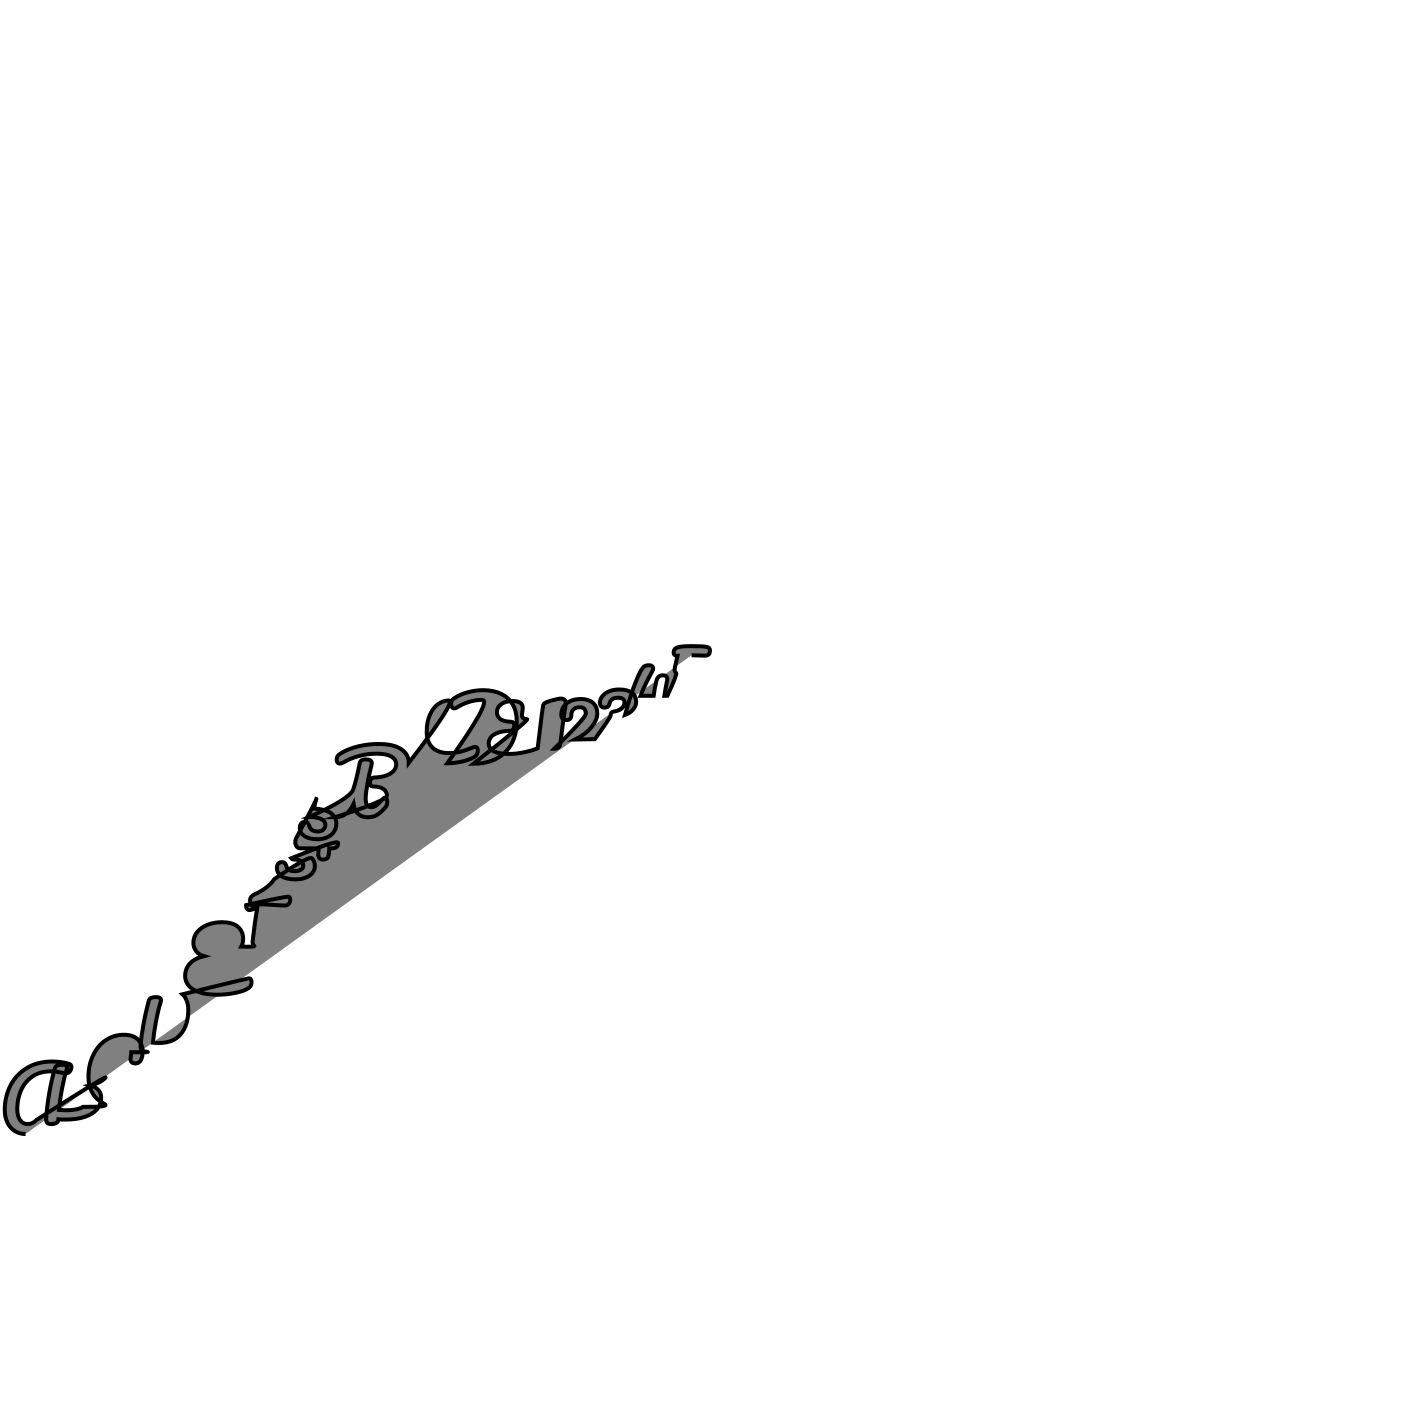

In [9]:
combinePath = Path(totalPath)
page = document(500, 500, 'mm').addpage()
pen = shape().stroke(rgba(0, 0, 0, 255)).fill(rgba(128, 128, 128, 255)).width(4)
page.place(pen.path(combinePath.scale(0.03).translate(0,400)))
show(page) # show the page